<a href="https://colab.research.google.com/github/fmezacr/AWS-Academy-/blob/main/MLPipeExample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

<div style="font-size:small;">

MIT License

Copyright (c) [2026] Felipe Meza-Obando

*Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software for educational purposes only. You must give author appropriate credit, provide a link to the license and source, and indicate if changes were made.*
</div>

---

# **MACHINE LEARNING END-TO-END** - **Customer Churn Prediction with XGBoost**


### Autor: **Dr. Ing. Felipe Meza-Obando**


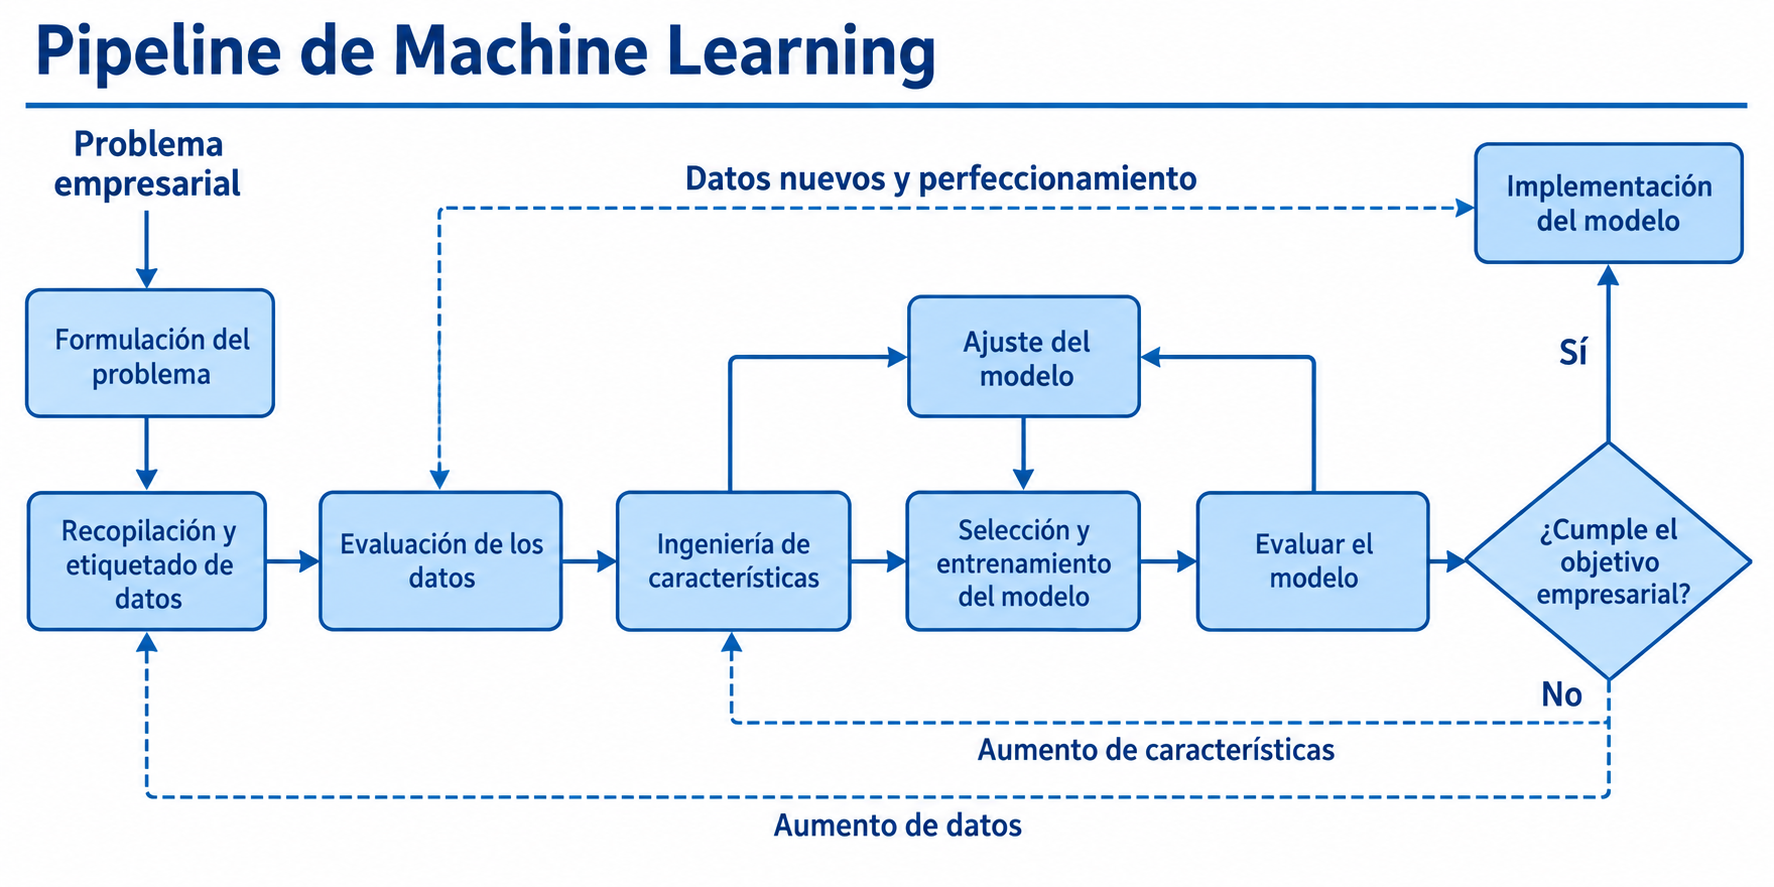

# Pipeline completo de Machine Learning: Predicción de Customer Churn

## Objetivo de la notebook

En esta notebook recorreremos las principales etapas de un proyecto de **Machine Learning supervisado**, desde la definición del problema empresarial hasta la evaluación e interpretación del modelo.

Trabajaremos con un problema frecuente en empresas de telecomunicaciones:

> **¿Podemos identificar qué clientes presentan mayor probabilidad de abandonar el servicio?**

Este fenómeno se conoce como **Customer Churn**.

Predecir churn puede ayudar a una empresa a priorizar acciones de retención, especialmente cuando los recursos disponibles para contactar clientes son limitados.

Seguiremos el flujo:

**Problema → Datos → EDA → Preparación → División Train/Test → Modelo → Entrenamiento → Predicción → Evaluación → Interpretación → Conclusiones**

Además de las métricas tradicionales de Machine Learning, incorporaremos una métrica orientada al negocio:

**¿Cuántos de los clientes que realmente abandonan el servicio podríamos identificar si solamente pudiéramos contactar al 20 % de la base de clientes?**

In [ ]:
%pip install -q pandas numpy matplotlib scikit-learn xgboost

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

from xgboost import XGBClassifier

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")



# 1. Definición del problema

Todo proyecto de Machine Learning debería comenzar por el problema que queremos resolver, no por el algoritmo.

## Problema empresarial

Una empresa de telecomunicaciones tiene miles de clientes.

Algunos permanecen con la empresa y otros cancelan el servicio.

Contactar a todos los clientes con campañas de retención puede ser costoso e ineficiente.

El objetivo es utilizar información disponible sobre cada cliente para estimar su **riesgo de churn** y ayudar a priorizar aquellos clientes que podrían requerir atención.

## Variable objetivo

La variable que queremos predecir es:

- `Churn = No`: el cliente permanece.
- `Churn = Yes`: el cliente abandona el servicio.

La transformaremos a:

- `0`: permanece.
- `1`: churn.

Estamos ante un problema de:

**Clasificación supervisada binaria**

porque tenemos ejemplos históricos donde conocemos las características de los clientes y también conocemos la clase que queremos predecir.

## Pregunta de Machine Learning

> A partir de las características de un cliente, ¿podemos estimar si pertenece al grupo con mayor riesgo de abandonar el servicio?

## Pregunta de negocio

> Si la empresa solamente pudiera contactar a una parte de sus clientes, ¿podría el modelo ayudar a concentrar los esfuerzos en aquellos con mayor riesgo?



# 2. Obtención y comprensión de los datos

Utilizaremos el dataset público **IBM Telco Customer Churn**.

Cada fila representa un cliente y las columnas incluyen información relacionada con:

- perfil del cliente,
- antigüedad,
- servicios contratados,
- tipo de contrato,
- método de pago,
- cargos mensuales,
- cargos acumulados,
- churn.

Fuente pública:

https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv

In [ ]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset cargado correctamente.")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

Dataset cargado correctamente.
Filas: 7,043
Columnas: 21


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.65,Yes


In [ ]:
print("Variables disponibles:\n")

for column in df.columns:
    print(column)


Variables disponibles:

customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Primera observación

El dataset contiene una combinación de:

- variables numéricas,
- variables categóricas,
- variables binarias,
- información contractual y financiera.

Esto es representativo de muchos problemas empresariales reales.

También observamos una columna llamada `customerID`.

Esta variable identifica al cliente, pero **no representa una característica útil para aprender patrones generales**, por lo que no será utilizada para entrenar el modelo.

In [ ]:
# Revisamos duplicados por identificador de cliente

duplicates = df["customerID"].duplicated().sum()

print(f"Identificadores duplicados: {duplicates}")

Identificadores duplicados: 0


# 3. Limpieza inicial y comprensión de los tipos de datos

Antes del EDA revisaremos un detalle importante.

La variable `TotalCharges` representa los cargos acumulados del cliente, por lo que conceptualmente debería ser numérica.

Comprobaremos su tipo de dato.


In [ ]:
print("Tipo original de TotalCharges:")
print(df["TotalCharges"].dtype)

print("\nEjemplos:")
print(df["TotalCharges"].head())

Tipo original de TotalCharges:
object

Ejemplos:
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: object


`TotalCharges` aparece como texto porque existen algunos registros vacíos.

Convertiremos esta variable a formato numérico.

Los valores que no puedan convertirse correctamente pasarán a ser valores faltantes (`NaN`).

No imputaremos todavía estos datos.

La imputación se realizará posteriormente **dentro del pipeline y utilizando únicamente el conjunto de entrenamiento**, para evitar data leakage.

In [ ]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Nuevo tipo de TotalCharges:")
print(df["TotalCharges"].dtype)

print("\nValores faltantes después de la conversión:")
print(df["TotalCharges"].isna().sum())

Nuevo tipo de TotalCharges:
float64

Valores faltantes después de la conversión:
11


In [ ]:
# Convertimos la variable objetivo a 0 y 1

df["Churn_flag"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

df[["Churn", "Churn_flag"]].head()

,Churn,Churn_flag
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


# 4. Análisis Exploratorio de Datos (EDA)

El objetivo del **Exploratory Data Analysis** no es crear muchas gráficas.

Queremos responder algunas preguntas relevantes antes de construir el modelo:

1. ¿Cuántos clientes abandonan el servicio?
2. ¿Existen datos faltantes?
3. ¿Hay variables que muestran patrones claramente diferentes entre clientes con y sin churn?
4. ¿Existen valores extremos?
5. ¿Qué implicaciones podrían tener estos hallazgos para el modelo?


## 4.1 Tasa de churn

Primero calcularemos uno de los indicadores empresariales más importantes del problema:

**Churn Rate**

$$
Churn\ Rate =
\frac{\text{Clientes que abandonan}}
{\text{Total de clientes}}
\times 100
$$

In [ ]:
churn_counts = df["Churn"].value_counts()
churn_rate = df["Churn_flag"].mean() * 100

print("Distribución de clientes:")
print(churn_counts)

print(f"\nChurn Rate: {churn_rate:.2f}%")

Distribución de clientes:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.54%


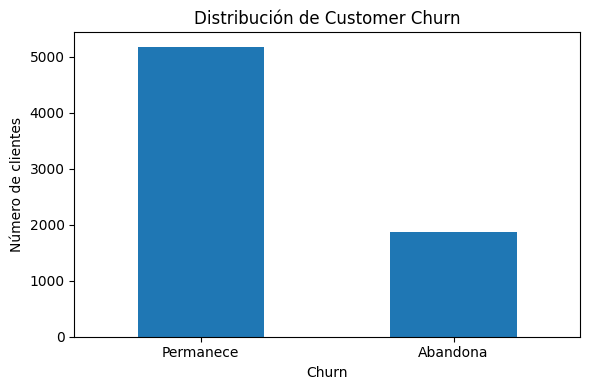

In [ ]:
ax = df["Churn"].value_counts().reindex(["No", "Yes"]).plot(
    kind="bar",
    figsize=(6, 4)
)

ax.set_title("Distribución de Customer Churn")
ax.set_xlabel("Churn")
ax.set_ylabel("Número de clientes")
ax.set_xticklabels(["Permanece", "Abandona"], rotation=0)

plt.tight_layout()
plt.show()

### Conclusión

La mayoría de los clientes permanece con la empresa, mientras que una proporción menor presenta churn.

Esto significa que las clases **no están perfectamente balanceadas**.

Por esa razón, evaluar el modelo únicamente con Accuracy podría ocultar errores importantes.

Posteriormente utilizaremos también:

- Precision,
- Recall,
- F1-score,
- ROC-AUC.

Además, evaluaremos qué tan útil podría ser el modelo para **priorizar clientes dentro de una campaña de retención**.

## 4.2 Valores faltantes

In [ ]:


missing = pd.DataFrame({
    "Missing": df.isna().sum(),
    "Percentage": df.isna().mean() * 100
})

missing = missing[missing["Missing"] > 0]

missing

,Missing,Percentage
TotalCharges,11,0.156



### Conclusión

Después de convertir `TotalCharges` a formato numérico aparecen algunos valores faltantes.

No los reemplazaremos utilizando información de todo el dataset.

La imputación será aprendida exclusivamente utilizando los datos de entrenamiento.

Esto es importante porque calcular estadísticas utilizando también el conjunto de prueba podría introducir **data leakage**.

## 4.3 Churn según tipo de contrato

Una primera pregunta empresarial interesante es:

> ¿La permanencia de los clientes parece variar según el tipo de contrato?

In [ ]:
contract_churn = (
    df.groupby("Contract", observed=False)["Churn_flag"]
    .agg(["count", "mean"])
    .rename(columns={
        "count": "Customers",
        "mean": "Churn_rate"
    })
)

contract_churn["Churn_rate"] *= 100

contract_churn.round(2)

,Customers,Churn_rate
Contract,,
Month-to-month,3875,42.710
One year,1473,11.270
Two year,1695,2.830


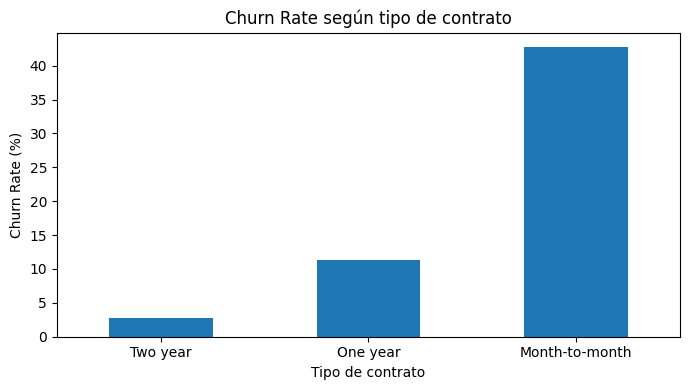

In [ ]:
contract_plot = contract_churn["Churn_rate"].sort_values()

ax = contract_plot.plot(
    kind="bar",
    figsize=(7, 4)
)

ax.set_title("Churn Rate según tipo de contrato")
ax.set_xlabel("Tipo de contrato")
ax.set_ylabel("Churn Rate (%)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Conclusión

El churn no se distribuye de la misma manera entre los diferentes tipos de contrato.

Esto sugiere que `Contract` puede contener información predictiva relevante.

Sin embargo, debemos hacer una distinción fundamental:

> Una relación observada entre una variable y churn no demuestra que esa variable sea la causa del churn.

Nuestro modelo buscará **patrones predictivos**, no relaciones causales.

## 4.4 Antigüedad del cliente

La variable `tenure` representa cuántos meses lleva el cliente con la empresa.

Analizaremos si existe alguna diferencia entre clientes que permanecen y clientes que abandonan.

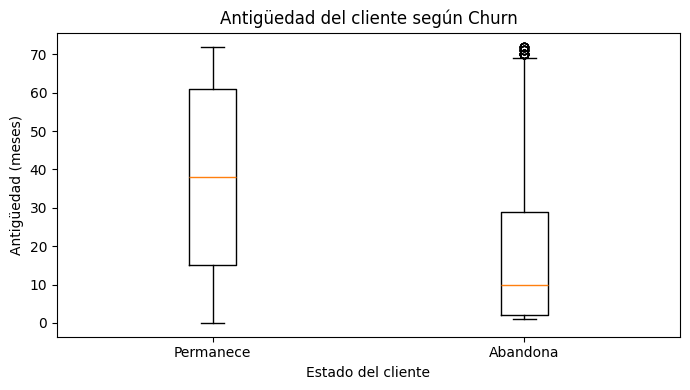

In [ ]:
tenure_no_churn = df.loc[
    df["Churn_flag"] == 0,
    "tenure"
]

tenure_churn = df.loc[
    df["Churn_flag"] == 1,
    "tenure"
]

plt.figure(figsize=(7, 4))

plt.boxplot(
    [tenure_no_churn, tenure_churn],
    tick_labels=["Permanece", "Abandona"]
)

plt.title("Antigüedad del cliente según Churn")
plt.xlabel("Estado del cliente")
plt.ylabel("Antigüedad (meses)")

plt.tight_layout()
plt.show()

In [ ]:
df.groupby("Churn")["tenure"].agg(
    ["count", "mean", "median"]
).round(2)

,count,mean,median
Churn,,,
No,5174,37.570,38.000
Yes,1869,17.980,10.000


### Conclusión

La distribución de antigüedad muestra diferencias entre clientes con y sin churn.

Por tanto, `tenure` podría ayudar al modelo a distinguir distintos perfiles de riesgo.

Este resultado también muestra por qué el EDA es importante:

antes de entrenar un modelo comenzamos a comprender **qué patrones podrían existir en los datos**.

## 4.5 Cargos mensuales


In [ ]:
monthly_summary = df.groupby("Churn")["MonthlyCharges"].agg(
    ["count", "mean", "median"]
)

monthly_summary.round(2)

,count,mean,median
Churn,,,
No,5174,61.270,64.430
Yes,1869,74.440,79.650


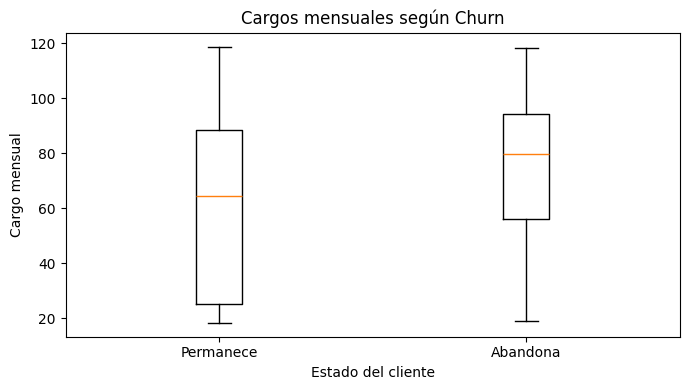

In [ ]:
monthly_no_churn = df.loc[
    df["Churn_flag"] == 0,
    "MonthlyCharges"
]

monthly_churn = df.loc[
    df["Churn_flag"] == 1,
    "MonthlyCharges"
]

plt.figure(figsize=(7, 4))

plt.boxplot(
    [monthly_no_churn, monthly_churn],
    tick_labels=["Permanece", "Abandona"]
)

plt.title("Cargos mensuales según Churn")
plt.xlabel("Estado del cliente")
plt.ylabel("Cargo mensual")

plt.tight_layout()
plt.show()

### Conclusión

Los cargos mensuales también muestran diferencias entre los dos grupos.

Esta variable podría aportar información útil al modelo.

Sin embargo, un modelo de Machine Learning no tomará decisiones observando una variable de manera aislada.

XGBoost puede aprender **combinaciones e interacciones entre múltiples características**.



## 4.6 Posibles valores atípicos

Analizaremos los cargos acumulados para observar posibles valores extremos.

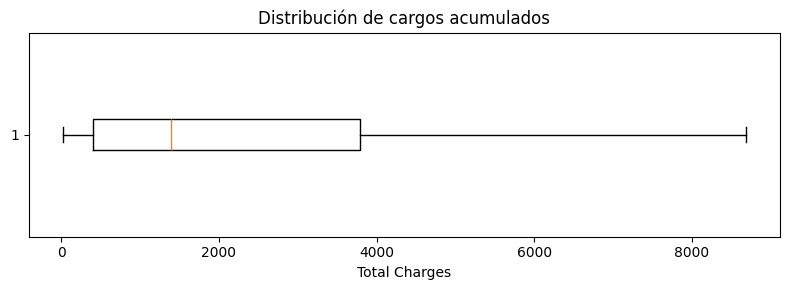

In [ ]:
plt.figure(figsize=(8, 3))

plt.boxplot(
    df["TotalCharges"].dropna(),
    vert=False
)

plt.title("Distribución de cargos acumulados")
plt.xlabel("Total Charges")

plt.tight_layout()
plt.show()

### Conclusión

La distribución contiene clientes con cargos acumulados considerablemente mayores que otros.

No eliminaremos automáticamente estos valores.

Un valor extremo no necesariamente representa un error.

Además, los algoritmos basados en árboles suelen ser menos sensibles a diferencias de escala y valores extremos que otros métodos.

# 5. Preparación de los datos

Una vez comprendidos los datos debemos definir qué información llegará al modelo.

El identificador `customerID` será eliminado porque solamente identifica cada observación.

La columna original `Churn` también será eliminada porque representa directamente el resultado que queremos predecir.

Utilizaremos `Churn_flag` como variable objetivo.

In [ ]:
target = "Churn_flag"

features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "MonthlyCharges",
    "TotalCharges"
]

X = df[features].copy()
y = df[target].copy()

print("Características:", X.shape)
print("Variable objetivo:", y.shape)

Características: (7043, 19)
Variable objetivo: (7043,)


# 6. División Train/Test

Separaremos los datos en:

- **80 % entrenamiento**
- **20 % prueba**

El conjunto de entrenamiento se utiliza para aprender los patrones del problema.

El conjunto de prueba simula datos que el modelo **no ha observado anteriormente**.

Esto permite evaluar su capacidad de **generalización**.

Utilizaremos `stratify=y` para mantener aproximadamente la misma proporción de churn en ambos conjuntos.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Entrenamiento: {X_train.shape}")
print(f"Prueba:        {X_test.shape}")

print("\nChurn rate en entrenamiento:")
print(f"{y_train.mean() * 100:.2f}%")

print("\nChurn rate en prueba:")
print(f"{y_test.mean() * 100:.2f}%")


Entrenamiento: (5634, 19)
Prueba:        (1409, 19)

Churn rate en entrenamiento:
26.54%

Churn rate en prueba:
26.54%


# 7. Preprocesamiento

Tenemos dos tipos principales de variables:

## Variables numéricas

Los valores faltantes serán sustituidos utilizando la **mediana** calculada exclusivamente con el conjunto de entrenamiento.

## Variables categóricas

Utilizaremos **One-Hot Encoding**.

Por ejemplo:

`Contract = Month-to-month / One year / Two year`

puede transformarse en varias columnas binarias.

## ¿Necesitamos normalizar?

Algoritmos como:

- KNN,
- SVM,
- regresión logística,
- redes neuronales,

pueden verse afectados por diferencias de escala.

XGBoost está basado en árboles de decisión y normalmente **no necesita que las variables numéricas sean estandarizadas**.

Por eso no aplicaremos normalización en este ejemplo.

In [ ]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

preprocessor

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])


## ¿Por qué utilizar un Pipeline?

El pipeline permite ejecutar de manera ordenada:

**Datos originales → Preprocesamiento → Modelo**

Además ayuda a evitar **data leakage**.

Por ejemplo, la mediana utilizada para completar `TotalCharges` se calcula solamente utilizando `X_train`.

La información del conjunto de prueba no participa en este proceso.


# 8. Selección del modelo: XGBoost

Utilizaremos **XGBoost — Extreme Gradient Boosting**.

XGBoost pertenece a una familia de algoritmos conocida como **boosting**.

## Árboles de decisión

Un árbol de decisión divide progresivamente los datos mediante reglas.

Por ejemplo:

> ¿El cliente tiene menos de cierto número de meses de antigüedad?

Después podría preguntar:

> ¿Qué tipo de contrato posee?

Estas divisiones forman ramas hasta producir una predicción.

## ¿Qué hace Boosting?

En lugar de construir un único árbol grande, boosting construye una **secuencia de árboles**.

De manera simplificada:

1. se construye un primer árbol;
2. se identifican los errores que todavía comete el modelo;
3. se construye un nuevo árbol para mejorar esas predicciones;
4. el proceso continúa de forma secuencial.

Cada nuevo árbol intenta mejorar el modelo construido hasta ese momento.

Podemos expresar la idea de manera simplificada como:

$$
\hat{y}^{(t)}
=
\hat{y}^{(t-1)}
+
\eta f_t(x)
$$

donde:

- $\hat{y}^{(t)}$: nueva predicción,
- $\hat{y}^{(t-1)}$: predicción anterior,
- $f_t(x)$: nuevo árbol,
- $\eta$: learning rate.

Por eso hablamos de **aprendizaje secuencial**.

# 9. Configuración del modelo

Utilizaremos algunos hiperparámetros importantes:

- `n_estimators`: número de árboles.
- `learning_rate`: tamaño de la contribución de cada nuevo árbol.
- `max_depth`: profundidad máxima de los árboles.
- `min_child_weight`: controla qué tan fácilmente se generan nuevas divisiones.
- `subsample`: proporción de observaciones utilizadas por árbol.
- `colsample_bytree`: proporción de características utilizadas por árbol.
- `reg_lambda`: regularización para controlar complejidad.

En esta notebook utilizaremos valores razonables para fines educativos.

En un proyecto real estos hiperparámetros podrían optimizarse mediante validación cruzada.

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=2,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", xgb_model)
    ]
)

model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.03,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None, min_child_weight=2,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

# 10. Entrenamiento

Durante el entrenamiento:

1. se aprende cómo imputar los valores faltantes;
2. se aprende cómo transformar las variables categóricas;
3. XGBoost recibe los datos procesados;
4. los árboles se construyen secuencialmente;
5. el modelo aprende patrones que permitan distinguir clientes con y sin churn.

Toda esta información se aprende utilizando **únicamente los datos de entrenamiento**.


In [ ]:
model.fit(
    X_train,
    y_train
)

print("Entrenamiento finalizado correctamente.")

Entrenamiento finalizado correctamente.


# 11. Predicción

El modelo puede producir dos tipos de salida.

## Clase predicha

- `0`: permanece.
- `1`: churn.

## Probabilidad

También puede producir un valor entre 0 y 1 que representa el nivel de riesgo estimado por el modelo.

Por ejemplo:

`0.82`

significa que el modelo asigna una probabilidad estimada relativamente alta a la clase churn.

Estas probabilidades son particularmente importantes para un problema de negocio porque permiten **ordenar clientes según riesgo**.

In [ ]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(
    X_test
)[:, 1]

predictions = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Churn_probability": y_prob
})

predictions.head(10)

,Actual,Predicted,Churn_probability
0,0,0,0.018
1,0,1,0.810
2,0,0,0.071
3,0,0,0.323
4,0,0,0.014
5,0,1,0.613
6,0,0,0.453
7,0,0,0.108
8,0,0,0.010
9,1,0,0.352


# 12. Evaluación del modelo

No existe una única métrica que describa completamente el comportamiento de un clasificador.

Utilizaremos varias.

## Accuracy

Porcentaje total de predicciones correctas.

## Precision

De todos los clientes que el modelo identificó como churn:

> ¿cuántos realmente abandonaron?

## Recall

De todos los clientes que realmente abandonaron:

> ¿cuántos logró detectar el modelo?

En un problema de retención esta métrica puede ser especialmente importante, porque un **falso negativo** corresponde a un cliente que abandona pero que el modelo no identificó como riesgo.

## F1-score

Combina Precision y Recall en una única métrica.

## ROC-AUC

Mide qué tan bien puede el modelo diferenciar clientes con y sin churn utilizando diferentes umbrales.

Un valor cercano a:

- `0.5`: capacidad de discriminación similar al azar.
- `1.0`: excelente separación entre las clases.

In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

metrics["Value"] = metrics["Value"].round(3)

metrics

,Metric,Value
0,Accuracy,0.806
1,Precision,0.668
2,Recall,0.532
3,F1-score,0.592
4,ROC-AUC,0.848


## ¿Por qué Accuracy no es suficiente?

Imagine que solamente una pequeña proporción de clientes abandona el servicio.

Un modelo podría predecir que **todos los clientes permanecen** y obtener una Accuracy aparentemente buena.

Sin embargo, desde el punto de vista empresarial sería prácticamente inútil porque no identificaría ningún cliente en riesgo.

Por eso debemos estudiar varias métricas simultáneamente.

In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Permanece",
            "Churn"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

   Permanece       0.84      0.90      0.87      1035
       Churn       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



# 13. Matriz de confusión

La matriz de confusión permite observar los cuatro resultados posibles:

- cliente permanece y el modelo lo predice correctamente;
- cliente abandona y el modelo lo predice correctamente;
- el modelo predice churn pero el cliente permanece;
- el cliente abandona pero el modelo no lo detecta.

Este último caso representa un **falso negativo**.

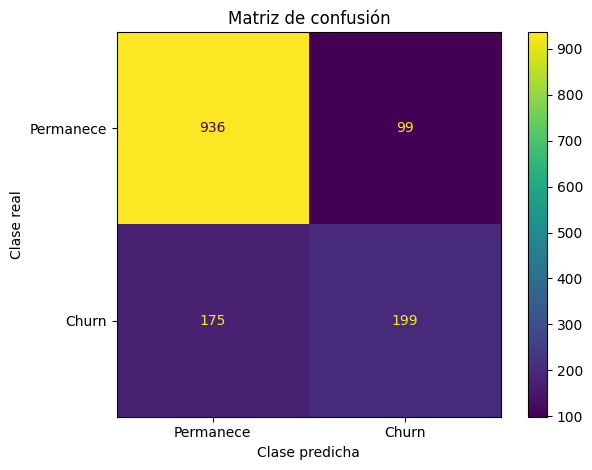

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Permanece",
        "Churn"
    ]
)

disp.plot(
    values_format="d"
)

plt.title("Matriz de confusión")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

plt.tight_layout()
plt.show()


### Conclusión

La matriz permite distinguir **qué tipo de error** está cometiendo el modelo.

Esta información puede ser más útil que observar solamente Accuracy.

En un contexto empresarial, falsos positivos y falsos negativos normalmente tienen **costos diferentes**.

# 14. Curva ROC

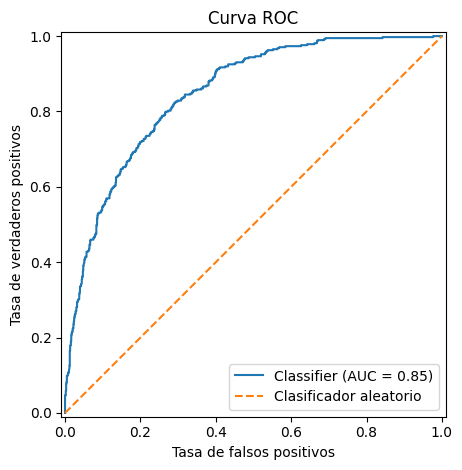

In [ ]:

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificador aleatorio"
)

plt.title("Curva ROC")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()

plt.tight_layout()
plt.show()

### Conclusión

La curva ROC evalúa el comportamiento del modelo utilizando diferentes umbrales de clasificación.

ROC-AUC resume esta capacidad en un único valor y permite evaluar qué tan bien el modelo ordena observaciones de ambas clases.

# 15. Generalización y Overfitting

Un modelo no debería evaluarse solamente sobre los datos utilizados para entrenarlo.

Compararemos el comportamiento en:

- entrenamiento,
- prueba.

Si el desempeño en entrenamiento es muy superior al desempeño en prueba, el modelo podría estar memorizando patrones específicos de los datos de entrenamiento.

Este fenómeno se conoce como **overfitting**.

In [ ]:
train_pred = model.predict(
    X_train
)

train_prob = model.predict_proba(
    X_train
)[:, 1]

train_metrics = {
    "Accuracy": accuracy_score(
        y_train,
        train_pred
    ),
    "F1-score": f1_score(
        y_train,
        train_pred
    ),
    "ROC-AUC": roc_auc_score(
        y_train,
        train_prob
    )
}

test_metrics = {
    "Accuracy": accuracy,
    "F1-score": f1,
    "ROC-AUC": roc_auc
}

generalization = pd.DataFrame({
    "Training": train_metrics,
    "Test": test_metrics
})

generalization["Difference"] = (
    generalization["Training"]
    -
    generalization["Test"]
)

generalization.round(3)

,Training,Test,Difference
Accuracy,0.821,0.806,0.015
F1-score,0.626,0.592,0.033
ROC-AUC,0.874,0.848,0.026


### Interpretación

Una pequeña diferencia entre entrenamiento y prueba es normal.

Debemos preocuparnos cuando el modelo presenta un desempeño muy alto sobre entrenamiento y claramente inferior sobre prueba.

La capacidad que realmente nos interesa es la capacidad de funcionar correctamente con **clientes que el modelo no observó durante el entrenamiento**.

# 16. Feature Importance

XGBoost puede proporcionar una estimación de la importancia de las características utilizadas durante el entrenamiento.

Esto nos ayuda a comprender qué información fue utilizada con mayor intensidad por el modelo.

Sin embargo:

> **Feature importance no significa causalidad.**

Una variable puede ser útil para predecir churn sin ser necesariamente la causa del churn.

In [ ]:
trained_preprocessor = model.named_steps[
    "preprocessor"
]

trained_model = model.named_steps[
    "classifier"
]

feature_names = (
    trained_preprocessor
    .get_feature_names_out()
)

importances = (
    trained_model
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

feature_importance.head(15)

,Feature,Importance
36,categorical__Contract_Month-to-month,0.353
16,categorical__InternetService_Fiber optic,0.088
18,categorical__OnlineSecurity_No,0.083
15,categorical__InternetService_DSL,0.063
27,categorical__TechSupport_No,0.059
43,categorical__PaymentMethod_Electronic check,0.029
38,categorical__Contract_Two year,0.028
1,numeric__tenure,0.023
37,categorical__Contract_One year,0.021
39,categorical__PaperlessBilling_No,0.018


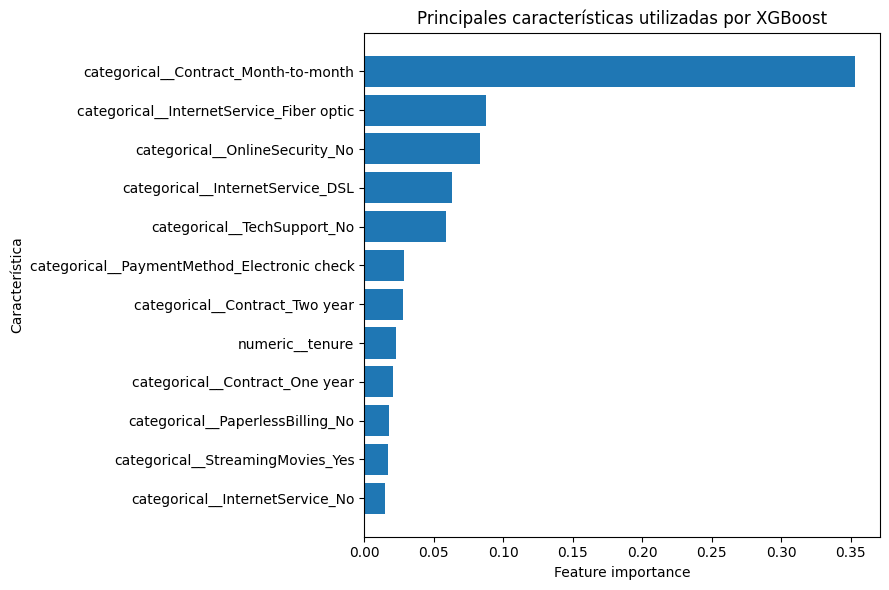

In [ ]:

top_features = (
    feature_importance
    .head(12)
    .sort_values(
        "Importance",
        ascending=True
    )
)

plt.figure(
    figsize=(9, 6)
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Principales características utilizadas por XGBoost"
)

plt.xlabel(
    "Feature importance"
)

plt.ylabel(
    "Característica"
)

plt.tight_layout()
plt.show()

### Conclusión

La gráfica permite identificar qué características tuvieron mayor participación en las decisiones del modelo.

Debemos interpretarla como:

**importancia predictiva para este modelo y estos datos**

y no como:

**causa del churn**.


# 17. Del Machine Learning a una decisión de negocio

Hasta este punto evaluamos el modelo utilizando métricas tradicionales.

Pero una empresa normalmente no pregunta:

> ¿Cuál es mi F1-score?

Una pregunta empresarial más natural sería:

> Si solamente tenemos capacidad para contactar al 20 % de los clientes, ¿qué clientes deberíamos priorizar?

Podemos utilizar la probabilidad generada por el modelo para ordenar clientes desde mayor hasta menor riesgo.

Después analizaremos cuántos clientes que realmente presentan churn aparecen dentro del **20 % de mayor riesgo**.

In [ ]:
business_results = X_test[
    [
        "MonthlyCharges",
        "tenure",
        "Contract"
    ]
].copy()

business_results["Actual_churn"] = y_test.values

business_results["Churn_probability"] = y_prob

business_results = (
    business_results
    .sort_values(
        "Churn_probability",
        ascending=False
    )
    .reset_index(drop=True)
)

business_results.head(10)


,MonthlyCharges,tenure,Contract,Actual_churn,Churn_probability
0,95.100,1,Month-to-month,1,0.923
1,95.450,1,Month-to-month,1,0.909
2,85.050,1,Month-to-month,1,0.909
3,76.450,1,Month-to-month,1,0.898
4,99.250,7,Month-to-month,1,0.898
5,77.150,1,Month-to-month,1,0.897
6,100.950,3,Month-to-month,1,0.894
7,101.950,7,Month-to-month,1,0.891
8,102.450,1,Month-to-month,1,0.881
9,105.900,3,Month-to-month,1,0.875


## 17.1 Campaña dirigida al 20 % de clientes de mayor riesgo

Supongamos que el equipo de retención solamente tiene capacidad para contactar al:

**20 % de los clientes**

No asumiremos cuánto cuesta una campaña ni cuánto dinero se recuperaría.

Solamente evaluaremos la capacidad del modelo para **concentrar clientes que realmente presentan churn dentro del grupo priorizado**.

In [ ]:
campaign_fraction = 0.20

n_customers = len(
    business_results
)

n_contact = int(
    np.ceil(
        n_customers
        *
        campaign_fraction
    )
)

priority_customers = (
    business_results
    .head(n_contact)
)

actual_churners = (
    business_results[
        "Actual_churn"
    ].sum()
)

churners_captured = (
    priority_customers[
        "Actual_churn"
    ].sum()
)

capture_rate = (
    churners_captured
    /
    actual_churners
)

precision_at_20 = (
    priority_customers[
        "Actual_churn"
    ].mean()
)

print(
    f"Clientes en conjunto de prueba: {n_customers:,}"
)

print(
    f"Clientes que podemos contactar: {n_contact:,}"
)

print(
    f"Clientes con churn real: {actual_churners:,}"
)

print(
    f"Churners encontrados en el grupo priorizado: {churners_captured:,}"
)

print(
    f"\nCapture Rate @20%: {capture_rate:.2%}"
)

print(
    f"Precision @20%: {precision_at_20:.2%}"
)

Clientes en conjunto de prueba: 1,409
Clientes que podemos contactar: 282
Clientes con churn real: 374
Churners encontrados en el grupo priorizado: 193

Capture Rate @20%: 51.60%
Precision @20%: 68.44%


## ¿Qué significa Capture Rate @20%?

Supongamos que existen 100 clientes que realmente abandonarán la empresa.

Si:

`Capture Rate @20% = 60 %`

significa que contactando únicamente al 20 % de clientes que el modelo considera de mayor riesgo encontraríamos aproximadamente:

**60 de los 100 clientes que realmente presentan churn.**

Esta métrica conecta directamente el modelo con una restricción empresarial:

**capacidad limitada de contacto.**

# 17.2 Lift

Podemos comparar la estrategia basada en Machine Learning con seleccionar clientes aleatoriamente.

Si seleccionáramos aleatoriamente el 20 % de los clientes, esperaríamos capturar aproximadamente el 20 % de los churners.

El **Lift** mide cuánto mejora el modelo respecto a esa referencia.

$$
Lift@20\% =
\frac{Capture\ Rate@20\%}
{20\%}
$$


In [ ]:
lift_at_20 = (
    capture_rate
    /
    campaign_fraction
)

print(
    f"Capture Rate @20%: {capture_rate:.2%}"
)

print(
    f"Lift @20%: {lift_at_20:.2f}x"
)

Capture Rate @20%: 51.60%
Lift @20%: 2.58x



### Interpretación del Lift

Por ejemplo:

`Lift = 2.5x`

significaría que la estrategia basada en el modelo concentra clientes con churn aproximadamente **2.5 veces mejor que una selección aleatoria** en ese segmento.

Esta métrica resulta especialmente útil en:

- campañas de retención,
- marketing dirigido,
- scoring de clientes,
- detección de fraude,
- priorización comercial.

Así podemos pasar de:

**¿El modelo predice bien?**

a una pregunta más cercana al negocio:

**¿El modelo ayuda a priorizar mejor nuestros recursos?**

# 17.3 Visualización del segmento priorizado


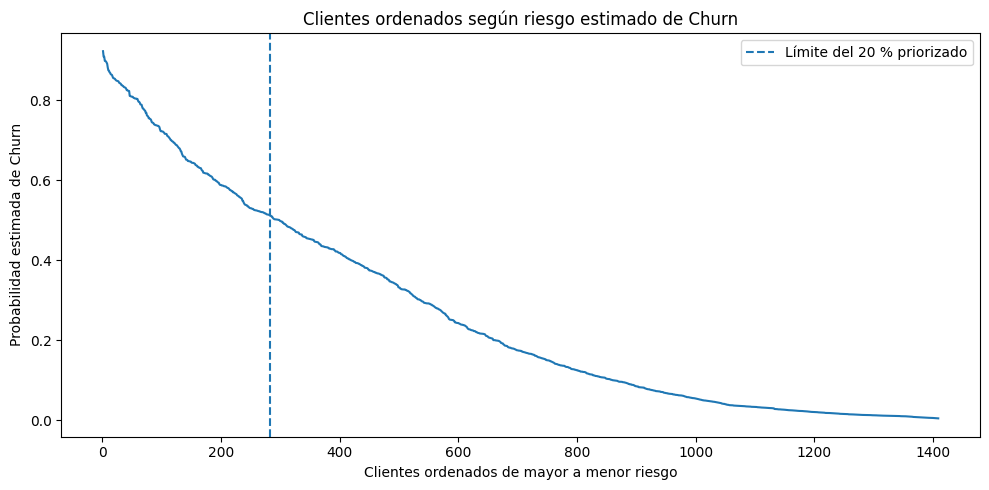

In [ ]:
business_plot = business_results.copy()

business_plot["Customer_rank"] = (
    np.arange(
        1,
        len(business_plot) + 1
    )
)

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    business_plot["Customer_rank"],
    business_plot["Churn_probability"]
)

plt.axvline(
    x=n_contact,
    linestyle="--",
    label="Límite del 20 % priorizado"
)

plt.title(
    "Clientes ordenados según riesgo estimado de Churn"
)

plt.xlabel(
    "Clientes ordenados de mayor a menor riesgo"
)

plt.ylabel(
    "Probabilidad estimada de Churn"
)

plt.legend()

plt.tight_layout()
plt.show()

### Conclusión empresarial

El modelo no tiene que utilizarse únicamente para producir una decisión binaria:

`Churn / No Churn`

Las probabilidades permiten construir un **ranking de riesgo**.

Esto puede resultar más útil para una empresa cuando existe una capacidad limitada de intervención.

El equipo podría comenzar por los clientes con mayor riesgo estimado y ampliar progresivamente la campaña según los recursos disponibles.

# 18. Ingreso mensual asociado a clientes en riesgo

Podemos añadir otra perspectiva descriptiva.

`MonthlyCharges` representa el cargo mensual actual de cada cliente.

Calcularemos la suma de los cargos mensuales asociados al grupo identificado como de mayor riesgo.

Esto **no representa una predicción de pérdida financiera**, porque para ello necesitaríamos información adicional sobre márgenes, permanencia futura, costos y efectividad de las acciones de retención.

Sin embargo, permite conectar el segmento identificado por el modelo con una variable económica observable.

In [ ]:
monthly_charges_priority = (
    priority_customers[
        "MonthlyCharges"
    ].sum()
)

monthly_charges_actual_churn = (
    business_results.loc[
        business_results[
            "Actual_churn"
        ] == 1,
        "MonthlyCharges"
    ].sum()
)

print(
    "Cargos mensuales asociados al 20 % priorizado:"
)

print(
    f"${monthly_charges_priority:,.2f}"
)

print(
    "\nCargos mensuales asociados a clientes que realmente presentan churn:"
)

print(
    f"${monthly_charges_actual_churn:,.2f}"
)

Cargos mensuales asociados al 20 % priorizado:
$22,058.55

Cargos mensuales asociados a clientes que realmente presentan churn:
$27,214.90



### Importante

Estos valores deben interpretarse como **cargos mensuales asociados a determinados grupos de clientes**, no como pérdidas financieras proyectadas.

Para estimar impacto financiero real necesitaríamos conocer, por ejemplo:

- margen por cliente,
- duración esperada de la relación,
- costo de la campaña,
- probabilidad de éxito de una intervención,
- costo de incentivos o descuentos.

Esto muestra una diferencia importante:

**un modelo predictivo no es automáticamente un modelo financiero.**

# 19. Resumen final automático

In [ ]:
train_auc = train_metrics[
    "ROC-AUC"
]

test_auc = test_metrics[
    "ROC-AUC"
]

auc_gap = (
    train_auc
    -
    test_auc
)

print(
    "=" * 60
)

print(
    "RESUMEN DEL MODELO"
)

print(
    "=" * 60
)

print(
    f"Accuracy       : {accuracy:.3f}"
)

print(
    f"Precision      : {precision:.3f}"
)

print(
    f"Recall         : {recall:.3f}"
)

print(
    f"F1-score       : {f1:.3f}"
)

print(
    f"ROC-AUC        : {roc_auc:.3f}"
)

print()

print(
    "=" * 60
)

print(
    "GENERALIZACIÓN"
)

print(
    "=" * 60
)

print(
    f"ROC-AUC entrenamiento : {train_auc:.3f}"
)

print(
    f"ROC-AUC prueba        : {test_auc:.3f}"
)

print(
    f"Diferencia            : {auc_gap:.3f}"
)

if auc_gap < 0.05:

    print(
        "La diferencia es pequeña: "
        "el modelo muestra una generalización razonable."
    )

elif auc_gap < 0.10:

    print(
        "Existe una diferencia moderada entre entrenamiento y prueba."
    )

else:

    print(
        "La diferencia es considerable y podría indicar overfitting."
    )

print()

print(
    "=" * 60
)

print(
    "IMPACTO PARA PRIORIZACIÓN"
)

print(
    "=" * 60
)

print(
    f"Clientes priorizados        : {campaign_fraction:.0%}"
)

print(
    f"Capture Rate @20%          : {capture_rate:.2%}"
)

print(
    f"Precision @20%             : {precision_at_20:.2%}"
)

print(
    f"Lift @20%                  : {lift_at_20:.2f}x"
)

RESUMEN DEL MODELO
Accuracy       : 0.806
Precision      : 0.668
Recall         : 0.532
F1-score       : 0.592
ROC-AUC        : 0.848

GENERALIZACIÓN
ROC-AUC entrenamiento : 0.874
ROC-AUC prueba        : 0.848
Diferencia            : 0.026
La diferencia es pequeña: el modelo muestra una generalización razonable.

IMPACTO PARA PRIORIZACIÓN
Clientes priorizados        : 20%
Capture Rate @20%          : 51.60%
Precision @20%             : 68.44%
Lift @20%                  : 2.58x




# 20. Conclusiones

En esta notebook recorrimos un proceso completo de Machine Learning utilizando un problema con aplicación empresarial.

## 1. Problema

Definimos una necesidad:

**identificar clientes con mayor riesgo de churn para apoyar la priorización de acciones de retención.**

## 2. Datos

Trabajamos con información relacionada con:

- características del cliente,
- servicios contratados,
- antigüedad,
- contrato,
- facturación,
- método de pago.

## 3. EDA

El análisis exploratorio permitió identificar:

- la proporción de churn,
- valores faltantes,
- diferencias según tipo de contrato,
- diferencias en antigüedad,
- diferencias en cargos mensuales,
- posibles valores extremos.

## 4. Preparación

Separamos variables numéricas y categóricas.

Aplicamos:

- imputación,
- One-Hot Encoding,
- Pipeline.

Todas las transformaciones fueron aprendidas utilizando únicamente los datos de entrenamiento para reducir el riesgo de **data leakage**.

## 5. Modelo

Utilizamos **XGBoost**, un algoritmo de boosting basado en múltiples árboles construidos secuencialmente.

## 6. Evaluación

Evaluamos el modelo utilizando:

- Accuracy,
- Precision,
- Recall,
- F1-score,
- ROC-AUC,
- matriz de confusión,
- curva ROC.

También comparamos entrenamiento y prueba para analizar **generalización y overfitting**.

## 7. Interpretación

Analizamos la importancia de características.

Recordamos que:

**importancia predictiva no implica causalidad.**

## 8. Valor empresarial

Finalmente dejamos de observar únicamente métricas de Machine Learning.

Ordenamos los clientes según su probabilidad estimada de churn y simulamos una situación donde el equipo solamente puede contactar al **20 % de la población**.

Utilizamos:

- `Capture Rate @20%`
- `Precision @20%`
- `Lift @20%`

Estas métricas responden una pregunta empresarial mucho más concreta:

> **¿Qué tan bien puede el modelo concentrar clientes realmente problemáticos dentro del segmento que la empresa puede atender?**

# Posibles mejoras

Este análisis representa un primer modelo.

Un proyecto real podría continuar con:

- validación cruzada;
- optimización de hiperparámetros;
- comparación con otros algoritmos;
- ingeniería de características;
- selección del umbral de decisión según costos;
- métricas Precision@K y Recall@K;
- curvas de Lift y Gains;
- calibración de probabilidades;
- análisis de equidad y sesgos;
- explicación individual de predicciones;
- incorporación de costos de retención;
- estimación del Customer Lifetime Value;
- evaluación de campañas mediante experimentos controlados;
- monitoreo del modelo una vez implementado.

# Pipeline completo seguido

## 1. Problema empresarial

¿Qué queremos resolver?

↓

## 2. Datos

¿Qué información tenemos?

↓

## 3. EDA

¿Qué podemos aprender antes de entrenar?

↓

## 4. Preparación

¿Cómo convertimos los datos a una representación apropiada?

↓

## 5. División Train/Test

¿Cómo evaluaremos datos que el modelo nunca observó?

↓

## 6. Modelo

¿Qué algoritmo utilizaremos?

↓

## 7. Entrenamiento

¿Cómo aprende el modelo?

↓

## 8. Predicción

¿Qué resultados produce?

↓

## 9. Evaluación

¿Qué tan bien funciona?

↓

## 10. Interpretación

¿Qué variables utiliza y qué errores comete?

↓

## 11. Evaluación empresarial

¿Ayuda a priorizar mejor los recursos?

↓

## 12. Conclusiones

¿Qué aprendimos y qué deberíamos mejorar?


### Flujo

**Problema → Datos → EDA → Preparación → Train/Test → Modelo → Entrenamiento → Predicción → Evaluación → Interpretación → Impacto empresarial → Conclusiones**

## Idea final

El algoritmo es solamente una parte de un proyecto de Machine Learning.

Un proyecto completo requiere:

**comprender el problema → comprender los datos → preparar correctamente la información → entrenar → evaluar → interpretar → conectar los resultados con una decisión real.**

> **Un modelo puede tener buenas métricas técnicas y aun así no generar valor si no ayuda a tomar una mejor decisión.**